In [69]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator
from sklearn.metrics import f1_score, average_precision_score, matthews_corrcoef, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, matthews_corrcoef
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv('data/receptor_std.csv')

In [35]:
df['mol'] = df['std_smiles'].apply(Chem.MolFromSmiles)

In [36]:
df.head(2)

,molecule_chembl_id,canonical_smiles,pKi,active,std_smiles,mol
0,CHEMBL542123,Br.C=CCN(C)CC[C@@]12CCCC[C@@H]1C=Cc1ccc(OC)cc12,7.309804,1,C=CCN(C)CC[C@@]12CCCC[C@@H]1C=Cc1ccc(OC)cc12,<rdkit.Chem.rdchem.Mol object at 0x00000203F30...
1,CHEMBL542217,Br.CC(C1CC1)N1CCC(C2CCc3ccccc3C2=O)CC1,7.585027,1,CC(C1CC1)N1CCC(C2CCc3ccccc3C2=O)CC1,<rdkit.Chem.rdchem.Mol object at 0x00000203F30...


## Scaffold Split
- 80/20
- larger scaffold series in train set

In [37]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    except:
        return ""

In [38]:
df['scaffold'] = df['std_smiles'].apply(get_scaffold)

In [39]:
scaffold_groups = df.groupby('scaffold').indices
scaffold_list = sorted(scaffold_groups.items(), key=lambda x: len(x[1]), reverse=True)

train_indices = []
test_indices = []
train_cutoff = int(0.8 * len(df))

In [40]:
for scaffold, indices in scaffold_list:
    if len(train_indices) + len(indices) <= train_cutoff:
        train_indices.extend(indices)
    else:
        test_indices.extend(indices)

df_train = df.iloc[train_indices].copy()
df_test = df.iloc[test_indices].copy()

print(f"Train set size: {len(df_train)}")
print(f"Test set size: {len(df_test)}")

Train set size: 2052
Test set size: 514


## Random Forest on Morgan fingerprints

In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
mfp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def generate_fps(smiles_list):
    fps = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        fps.append(mfp_gen.GetFingerprintAsNumPy(mol))
    return np.array(fps)

In [43]:
X_train = generate_fps(df_train['std_smiles'])
y_train = df_train['active'].values

X_test = generate_fps(df_test['std_smiles'])
y_test = df_test['active'].values

In [44]:
def generate_scaffold_folds(df, n_folds=5):
    scaffold_groups = df.groupby('scaffold').indices
    scaffold_list = sorted(scaffold_groups.items(), key=lambda x: len(x[1]), reverse=True)
    
    folds = [[] for _ in range(n_folds)]
    
    for scaffold, indices in scaffold_list:
        smallest_fold_idx = np.argmin([len(f) for f in folds])
        folds[smallest_fold_idx].extend(indices)
        
    cv_splits = []
    
    for i in range(n_folds):
        val_idx = folds[i]
        train_idx = []
        for j in range(n_folds):
            if i != j:
                train_idx.extend(folds[j])
        cv_splits.append((train_idx, val_idx))
        
    return cv_splits

In [45]:
custom_cv = generate_scaffold_folds(df_train, n_folds=5)

In [46]:
param_distributions = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

mcc_scorer = make_scorer(matthews_corrcoef)

In [47]:
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=param_distributions,
    n_iter=20,
    scoring=mcc_scorer,
    cv=custom_cv,
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

print(f"Best MCC during CV: {rf_search.best_score_:.3f}")
print("Best parameters:")
for param, value in rf_search.best_params_.items():
    print(f"    {param}: {value}")

best_model_rf = rf_search.best_estimator_
y_pred_rf = best_model_rf.predict(X_test)

mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print("\n--- Evaluation on test set ---")
print(f"Test MCC: {mcc_rf:.3f}")
print("Test F1 Score:", f1_score(y_test, y_pred_rf))
print("Test confusion matrix (TN, FP | FN, TP):\n", conf_matrix_rf)

Best MCC during CV: 0.547
Best parameters:
    n_estimators: 200
    min_samples_split: 10
    min_samples_leaf: 4
    max_features: sqrt
    max_depth: None

--- Evaluation on test set ---
Test MCC: 0.559
Test F1 Score: 0.8456973293768546
Test confusion matrix (TN, FP | FN, TP):
 [[125  68]
 [ 36 285]]


## XGBoost on ErG fingerprints

In [49]:
from xgboost import XGBClassifier
from rdkit.Chem.rdReducedGraphs import GetErGFingerprint

In [50]:
def generate_erg_fps(smiles_list):
    fps = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        fps.append(GetErGFingerprint(mol))
    return np.array(fps)

X_train_erg = generate_erg_fps(df_train['std_smiles'])
X_test_erg = generate_erg_fps(df_test['std_smiles'])

In [51]:
num_neg = np.sum(y_train == 0)
num_pos = np.sum(y_train == 1)
scale_weight = num_neg / num_pos

In [52]:
param_distributions_xgb = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_weight, 
        random_state=42, 
        eval_metric='logloss'
    ),
    param_distributions=param_distributions_xgb,
    n_iter=20,
    scoring=mcc_scorer,
    cv=custom_cv,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train_erg, y_train)

for param, value in xgb_search.best_params_.items():
    print(f"    {param}: {value}")

    subsample: 0.8
    n_estimators: 200
    max_depth: 7
    learning_rate: 0.05
    gamma: 0.5
    colsample_bytree: 1.0


In [53]:
best_model_xgb = xgb_search.best_estimator_
y_pred_xgb = best_model_xgb.predict(X_test_erg)

mcc_xgb = matthews_corrcoef(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"Test MCC: {mcc_xgb:.3f}")
print("Test F1 Score:", f1_score(y_test, y_pred_xgb))
print("Test confusion matrix (TN, FP | FN, TP):\n", conf_matrix_xgb)

Test MCC: 0.557
Test F1 Score: 0.8416289592760181
Test confusion matrix (TN, FP | FN, TP):
 [[130  63]
 [ 42 279]]


## Logistic Regression on Mordred descriptors

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [55]:
df_mordred = pd.read_csv('data/data.csv')

In [10]:
df_mordred.isna().any().sum()

np.int64(371)

Many descriptors produce null values, but since there are around 1300 in total, dropping the 300 is easier than dealing with them

In [13]:
df_mordred_clean = df_mordred.dropna(axis=1).copy()

In [15]:
metadata_cols = ['molecule_chembl_id', 'canonical_smiles', 'pKi', 'active', 'source_count', 'mol']
feature_cols = [col for col in df_mordred_clean.columns if col not in metadata_cols]

In [16]:
train_merged = df_train[['molecule_chembl_id']].merge(df_mordred_clean, on='molecule_chembl_id', how='left')
test_merged = df_test[['molecule_chembl_id']].merge(df_mordred_clean, on='molecule_chembl_id', how='left')

In [18]:
X_train_mordred_raw = train_merged[feature_cols].values
X_test_mordred_raw = test_merged[feature_cols].values

scaler = StandardScaler()

X_train_mordred = scaler.fit_transform(X_train_mordred_raw)
X_test_mordred = scaler.transform(X_test_mordred_raw)

In [20]:
mcc_scorer = make_scorer(matthews_corrcoef)

In [ ]:
param_distributions_en = {
    'C': [0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9],
    'class_weight': ['balanced']
}

en_search = RandomizedSearchCV(
    estimator=LogisticRegression(penalty='elasticnet', solver='saga', tol=1e-3, random_state=42, max_iter=5000),
    param_distributions=param_distributions_en,
    n_iter=10,
    scoring=mcc_scorer,
    cv=custom_cv,
    n_jobs=-1,
    random_state=42,
    verbose=3
)

print("Starting ElasticNet hyperparameter search...")
en_search.fit(X_train_mordred, y_train)

Starting ElasticNet hyperparameter search...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\Users\barca\miniconda3\envs\CADD\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LogisticRegre...a', tol=0.001)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.01, 0.1, ...], 'class_weight': ['balanced'], 'l1_ratio': [0.1, 0.5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",make_scorer(m...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 `

In [32]:
print(f"Best MCC during CV: {en_search.best_score_:.3f}")
print("Best parameters:")
for param, value in en_search.best_params_.items():
    print(f"    {param}: {value}")

best_model_lr = en_search.best_estimator_
y_pred_lr = best_model_lr.predict(X_test_mordred)

mcc_lr = matthews_corrcoef(y_test, y_pred_lr)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

print("\n--- Evaluation on test set ---")
print(f"Test MCC: {mcc_lr:.3f}")
print("Test F1 Score:", f1_score(y_test, y_pred_lr))
print("Test confusion matrix (TN, FP | FN, TP):\n", conf_matrix_lr)

Best MCC during CV: 0.551
Best parameters:
    l1_ratio: 0.9
    class_weight: balanced
    C: 10

--- Evaluation on test set ---
Test MCC: 0.518
Test F1 Score: 0.8238897396630934
Test confusion matrix (TN, FP | FN, TP):
 [[130  63]
 [ 52 269]]


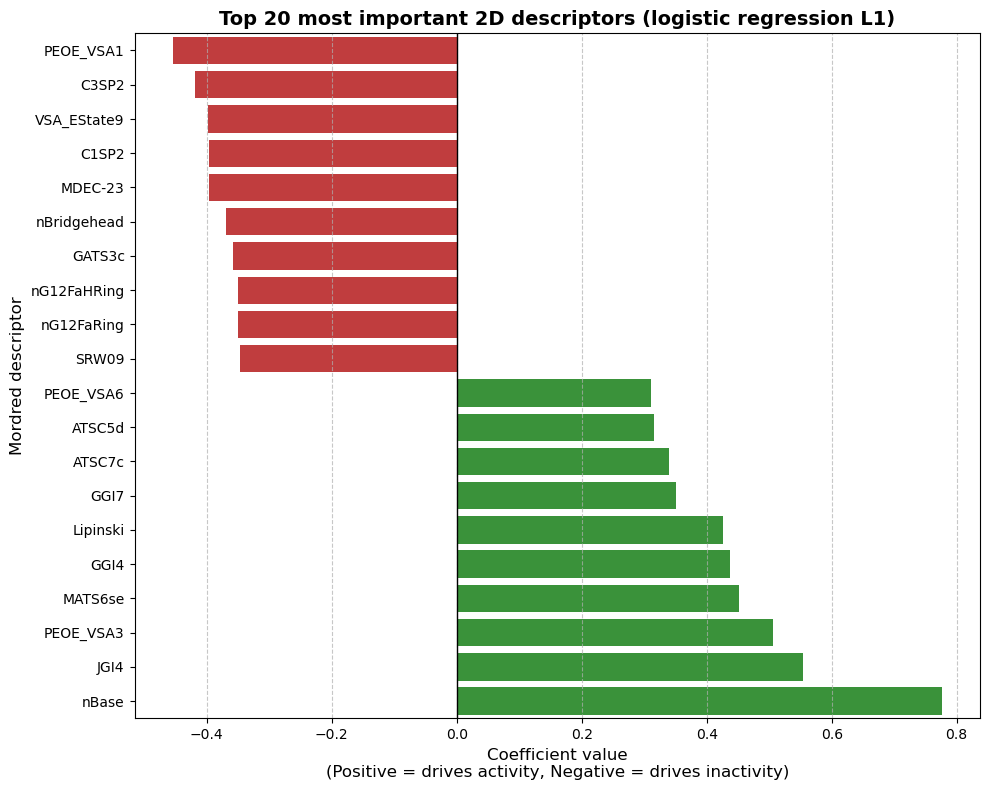

Total features originally: 938
Features retained by L1 penalty (non-zero coefficients): 929


In [70]:
coefficients = best_model_lr.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

active_features = feature_importance[feature_importance['Coefficient'] != 0].copy()
top_features = active_features.sort_values(by='Abs_Coefficient', ascending=False).head(20)
top_features = top_features.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(10, 8))

colors = ['#d62728' if val < 0 else '#2ca02c' for val in top_features['Coefficient']]

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature',
    palette=colors,
    hue='Feature',
    legend=False
)

plt.title('Top 20 most important 2D descriptors (logistic regression L1)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient value\n(Positive = drives activity, Negative = drives inactivity)', fontsize=12)
plt.ylabel('Mordred descriptor', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Output the feature selection metrics
print(f"Total features originally: {len(feature_cols)}")
print(f"Features retained by L1 penalty (non-zero coefficients): {len(active_features)}")

## Comparison

In [57]:
pr_auc_rf = average_precision_score(y_test, best_model_rf.predict_proba(X_test)[:, 1])
pr_auc_xgb = average_precision_score(y_test, best_model_xgb.predict_proba(X_test_erg)[:, 1])
pr_auc_lr = average_precision_score(y_test, best_model_lr.predict_proba(X_test_mordred)[:, 1])

In [58]:
results_df = pd.DataFrame({
    'Model': ['Random Forest (Morgan)', 'XGBoost (ErG)', 'Logistic Regression (Mordred)'],
    'MCC': [mcc_rf, mcc_xgb, mcc_lr],
    'PR AUC': [pr_auc_rf, pr_auc_xgb, pr_auc_lr]
})

In [63]:
styled_table = (
    results_df.style
    .highlight_max(subset=['MCC', 'PR AUC'], color="#028602", axis=0)
    .format({'MCC': '{:.3f}', 'PR AUC': '{:.3f}'})
    .set_properties(**{'text-align': 'center', 'border': '1px solid black'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]}])
    .hide(axis='index')
)

display(styled_table)

Model,MCC,PR AUC
Random Forest (Morgan),0.559,0.902
XGBoost (ErG),0.557,0.887
Logistic Regression (Mordred),0.518,0.862


In [64]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[1, 0])
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=[1, 0])
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=[1, 0])

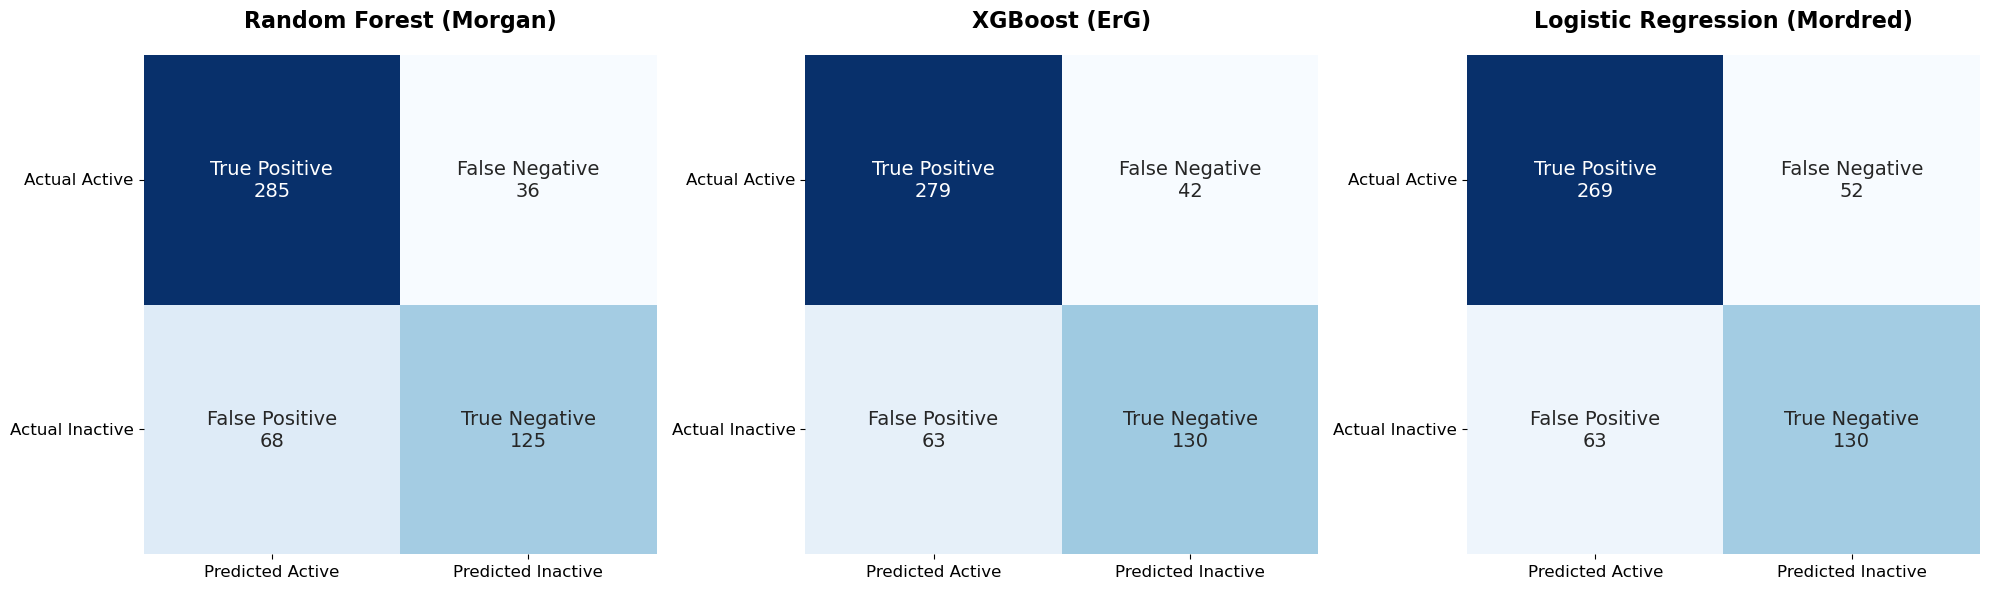

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_cms = [
    ('Random Forest (Morgan)', cm_rf),
    ('XGBoost (ErG)', cm_xgb),
    ('Logistic Regression (Mordred)', cm_lr)
]

group_names = [
    ['True Positive', 'False Negative'], 
    ['False Positive', 'True Negative']
]

for ax, (title, cm) in zip(axes, models_cms):
    labels = np.asarray([
        [f"{group_names[i][j]}\n{cm[i, j]}" for j in range(2)] 
        for i in range(2)
    ])
    
    sns.heatmap(
        cm, 
        annot=labels, 
        fmt='', 
        cmap='Blues', 
        cbar=False, 
        ax=ax, 
        annot_kws={"size": 14}, # Increase text size for presentations
        xticklabels=['Predicted Active', 'Predicted Inactive'],
        yticklabels=['Actual Active', 'Actual Inactive']
    )
    
    ax.set_title(title, fontsize=16, pad=20, fontweight='bold')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)

plt.tight_layout()
plt.show()